In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
df = sns.load_dataset('titanic')



print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print(df.head())


✅ Dataset loaded successfully!
Shape: 891 rows × 15 columns

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print(df.describe(include='all'))

print("\n" + "=" * 50)
print("COLUMN DATA TYPES")
print("=" * 50)
print(df.dtypes)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

STATISTICAL SUMMARY
          survived      pclass   sex         

In [4]:
print("=" * 50)
print("MISSING VALUE COUNT PER COLUMN")
print("=" * 50)
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

MISSING VALUE COUNT PER COLUMN
             Missing Count  Missing %
deck                   688      77.22
age                    177      19.87
embarked                 2       0.22
embark_town              2       0.22

Total missing values in dataset: 869


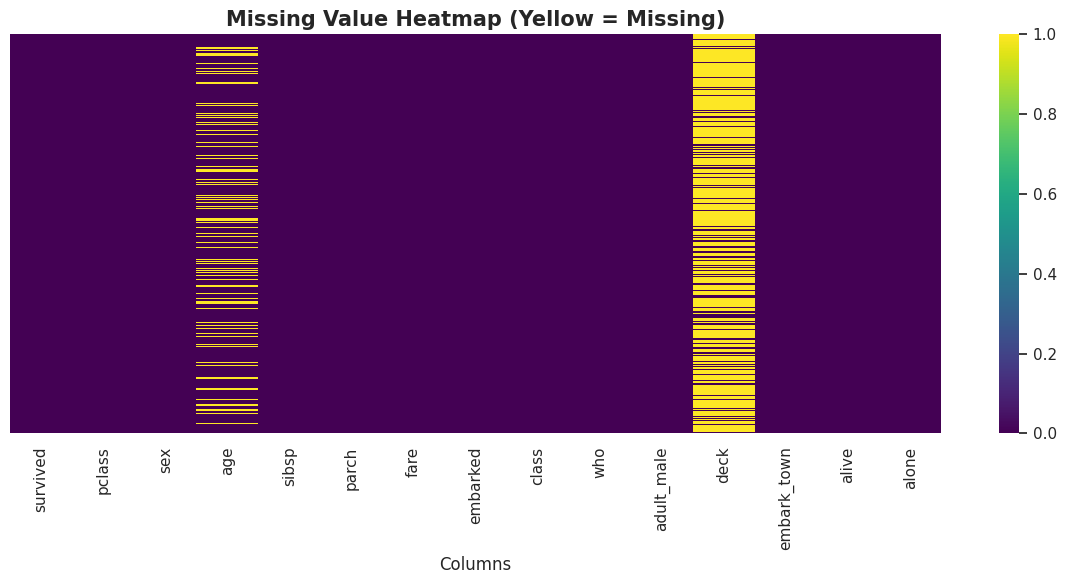

✅ Heatmap saved as 'missing_heatmap.png'


In [5]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)', fontsize=15, fontweight='bold')
plt.xlabel('Columns')
plt.tight_layout()
plt.savefig('missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved as 'missing_heatmap.png'")


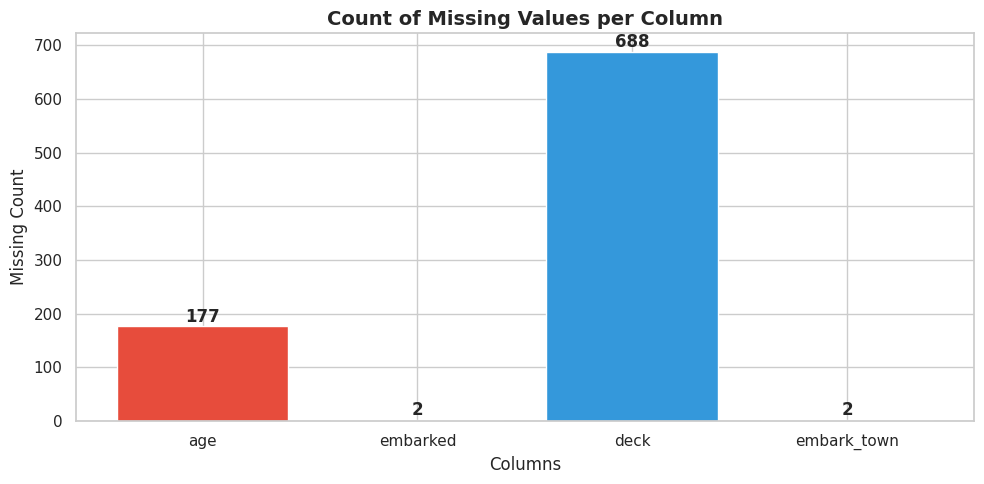

✅ Bar chart saved as 'missing_bar.png'


In [6]:
missing_only = df.isnull().sum()
missing_only = missing_only[missing_only > 0]

plt.figure(figsize=(10, 5))
bars = plt.bar(missing_only.index, missing_only.values, color=['#e74c3c', '#e67e22', '#3498db'])
plt.title('Count of Missing Values per Column', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Missing Count')
for bar, val in zip(bars, missing_only.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('missing_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bar chart saved as 'missing_bar.png'")

In [8]:
# --- Keep a copy of raw data for comparison ---
df_raw = df.copy()
df_clean = df.copy()

print("BEFORE CLEANING:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print()

# ── 7a. Drop the 'deck' column (>77% missing — too much to impute) ──
df_clean.drop(columns=['deck'], inplace=True)
print("✅ Dropped 'deck' column (77% missing — not worth imputing)")

# ── 7b. Drop 'embark_town' and 'embarked' duplicate columns ──
# 'embarked' and 'embark_town' carry the same info — keep 'embarked'
df_clean.drop(columns=['embark_town'], inplace=True)
print("✅ Dropped 'embark_town' (duplicate of 'embarked')")

# ── 7c. Impute 'age' with MEDIAN (robust to outliers) ──
age_imputer = SimpleImputer(strategy='median')
df_clean['age'] = age_imputer.fit_transform(df_clean[['age']])
print(f"✅ Imputed 'age' with Median = {df_raw['age'].median()}")

# ── 7d. Impute 'embarked' with MODE (categorical column) ──
mode_imputer = SimpleImputer(strategy='most_frequent')
df_clean['embarked'] = mode_imputer.fit_transform(df_clean[['embarked']]).ravel()
print(f"✅ Imputed 'embarked' with Mode = '{df_raw['embarked'].mode()[0]}'")

# ── 7e. Drop rows where 'alive' column is missing ──
df_clean.dropna(subset=['alive'], inplace=True)
print(f"✅ Dropped rows with missing 'alive' values")

print("\nAFTER CLEANING:")
remaining = df_clean.isnull().sum()[df_clean.isnull().sum() > 0]
if remaining.empty:
    print("🎉 No missing values remain!")
else:
    print(remaining)

BEFORE CLEANING:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

✅ Dropped 'deck' column (77% missing — not worth imputing)
✅ Dropped 'embark_town' (duplicate of 'embarked')
✅ Imputed 'age' with Median = 28.0
✅ Imputed 'embarked' with Mode = 'S'
✅ Dropped rows with missing 'alive' values

AFTER CLEANING:
🎉 No missing values remain!


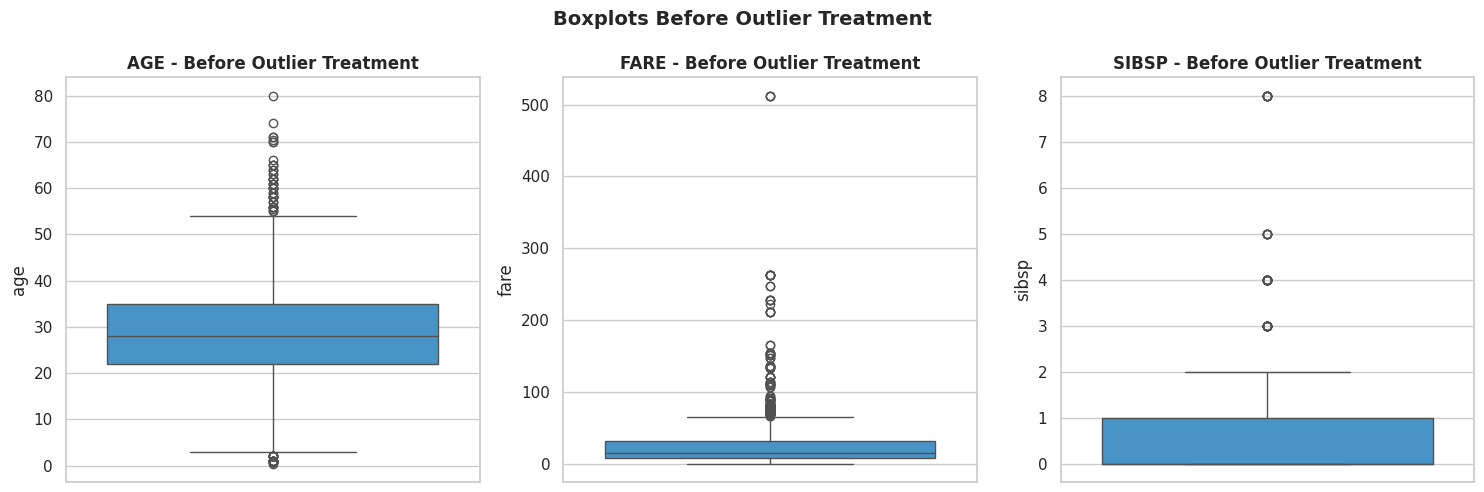

✅ Saved 'outliers_before.png'

Capping outliers using IQR method:
  age: 66 outliers capped → [2.50, 54.50]
  fare: 116 outliers capped → [-26.72, 65.63]
  sibsp: 46 outliers capped → [-1.50, 2.50]
  parch: 213 outliers capped → [0.00, 0.00]


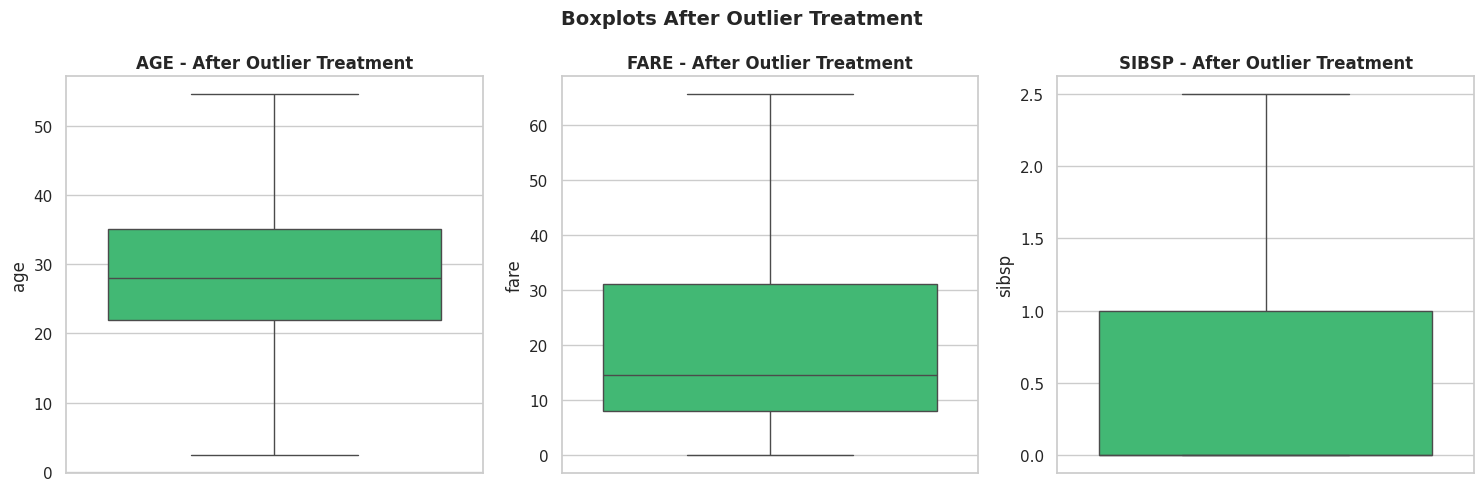

✅ Saved 'outliers_after.png'


In [9]:
# ── 8a. Boxplots BEFORE outlier treatment ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['age', 'fare', 'sibsp']):
    sns.boxplot(y=df_clean[col], ax=ax, color='#3498db')
    ax.set_title(f'{col.upper()} - Before Outlier Treatment', fontweight='bold')
plt.suptitle('Boxplots Before Outlier Treatment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_before.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 'outliers_before.png'")

# ── 8b. IQR-based Outlier Capping (Winsorization) ──
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  {col}: {before} outliers capped → [{lower:.2f}, {upper:.2f}]")
    return df

print("\nCapping outliers using IQR method:")
for col in ['age', 'fare', 'sibsp', 'parch']:
    df_clean = cap_outliers_iqr(df_clean, col)

# ── 8c. Boxplots AFTER outlier treatment ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['age', 'fare', 'sibsp']):
    sns.boxplot(y=df_clean[col], ax=ax, color='#2ecc71')
    ax.set_title(f'{col.upper()} - After Outlier Treatment', fontweight='bold')
plt.suptitle('Boxplots After Outlier Treatment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 'outliers_after.png'")

In [10]:
print("=" * 50)
print("FINAL DATASET VERIFICATION")
print("=" * 50)
print(f"Original shape : {df_raw.shape}")
print(f"Cleaned shape  : {df_clean.shape}")
print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")
print(f"\nDuplicate rows: {df_clean.duplicated().sum()}")

# Drop any duplicate rows
df_clean.drop_duplicates(inplace=True)
print(f"Duplicates after removal: {df_clean.duplicated().sum()}")

print(f"\n✅ FINAL SHAPE: {df_clean.shape}")
print("\nCleaned Dataset Sample:")
print(df_clean.head(10))

FINAL DATASET VERIFICATION
Original shape : (891, 15)
Cleaned shape  : (891, 13)

Missing values remaining: 0

Duplicate rows: 130
Duplicates after removal: 0

✅ FINAL SHAPE: (761, 13)

Cleaned Dataset Sample:
   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0    1.0      0   7.2500        S   Third   
1         1       1  female  38.0    1.0      0  65.6344        C   First   
2         1       3  female  26.0    0.0      0   7.9250        S   Third   
3         1       1  female  35.0    1.0      0  53.1000        S   First   
4         0       3    male  35.0    0.0      0   8.0500        S   Third   
5         0       3    male  28.0    0.0      0   8.4583        Q   Third   
6         0       1    male  54.0    0.0      0  51.8625        S   First   
7         0       3    male   2.5    2.5      0  21.0750        S   Third   
8         1       3  female  27.0    0.0      0  11.1333        S   Third   
9         1       2 

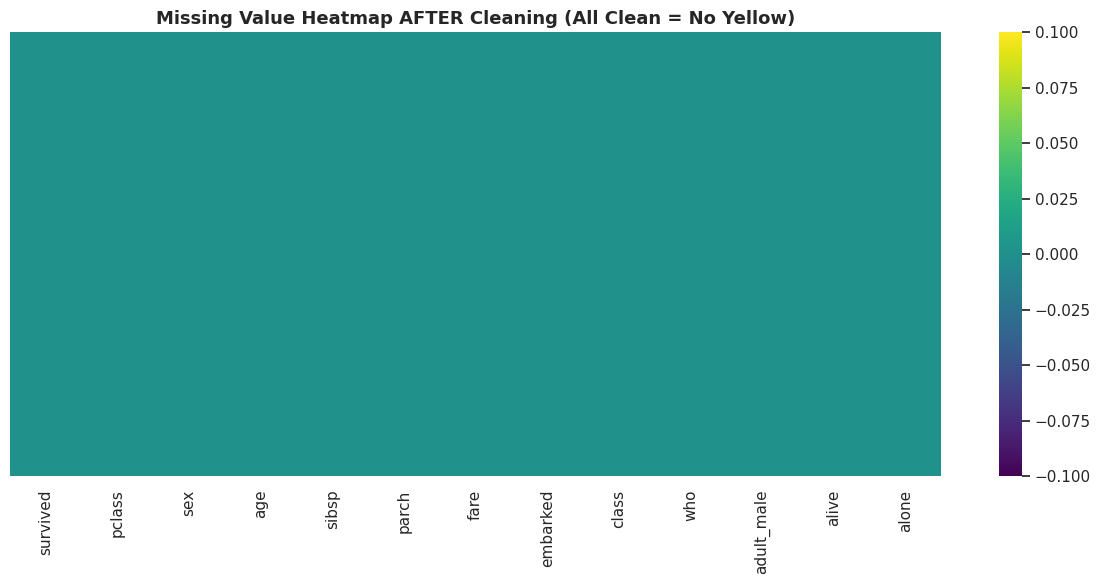

✅ Saved 'final_heatmap.png'


In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_clean.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap AFTER Cleaning (All Clean = No Yellow)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 'final_heatmap.png'")


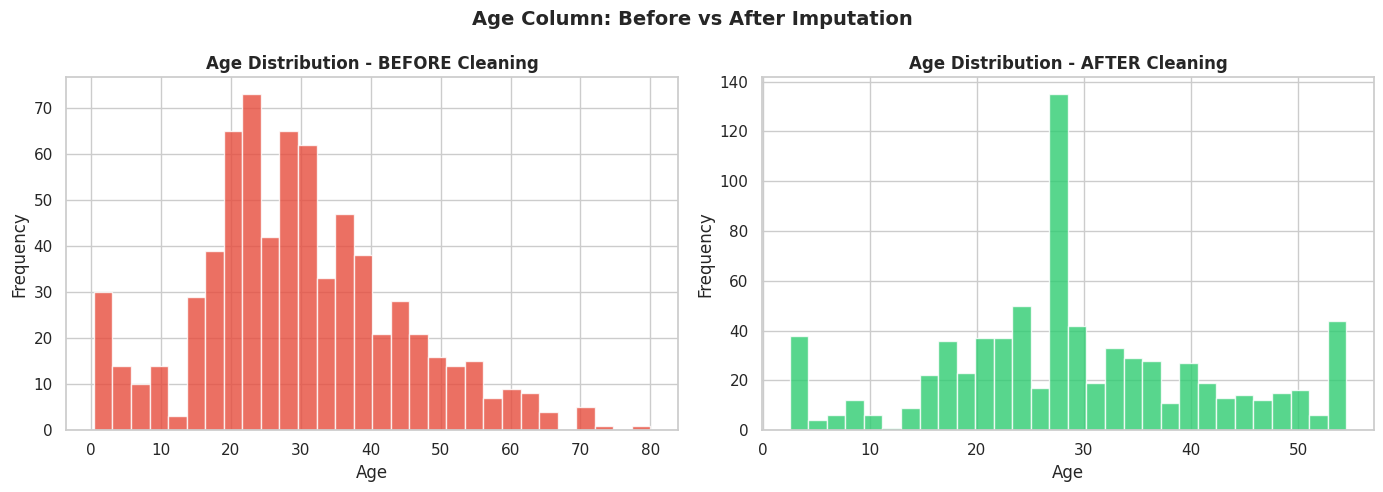

✅ Saved 'age_comparison.png'


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['age'].dropna(), bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title('Age Distribution - BEFORE Cleaning', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_clean['age'], bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('Age Distribution - AFTER Cleaning', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

plt.suptitle('Age Column: Before vs After Imputation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('age_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 'age_comparison.png'")


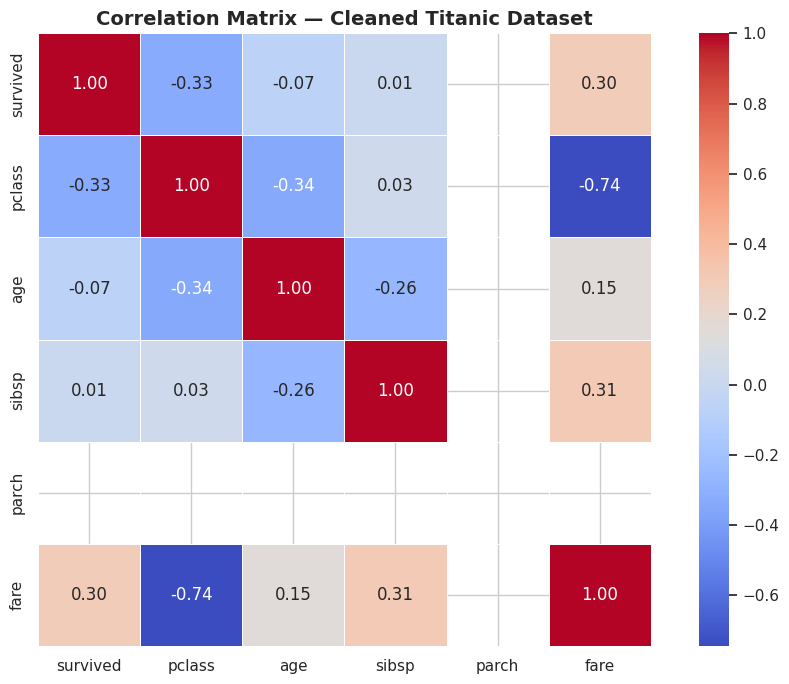

✅ Saved 'correlation_heatmap.png'


In [13]:
numeric_df = df_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Cleaned Titanic Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 'correlation_heatmap.png'")


In [14]:
df_clean.to_csv('titanic_cleaned.csv', index=False)
print("✅ Cleaned dataset exported as 'titanic_cleaned.csv'")
print(f"Final rows: {df_clean.shape[0]}, Final columns: {df_clean.shape[1]}")

# For Google Colab — auto-download the file
try:
    from google.colab import files
    files.download('titanic_cleaned.csv')
    print("✅ File downloaded to your computer!")
except:
    print("ℹ️  Not running in Colab. File saved to current directory.")

✅ Cleaned dataset exported as 'titanic_cleaned.csv'
Final rows: 761, Final columns: 13


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File downloaded to your computer!
